# DSAA2011 Course Project: Air Quality Dataset Analysis

## Project Overview

This project applies machine learning techniques to the **UCI Air Quality Dataset**, which contains 9,358 hourly-averaged readings from 5 metal-oxide chemical sensors deployed in an Italian city. Our analysis pipeline covers:

1. **Data Preprocessing**: Handling missing values (-200 sentinel codes), temporal interpolation, and feature standardization.
2. **Data Visualization**: t-SNE projection (2D & 3D) with AQI-inspired multi-level coloring for high-dimensional sensor data exploration.
3. **Clustering Analysis**: Five complementary algorithms (K-Means, Agglomerative, DBSCAN, GMM, Spectral) with multi-metric evaluation.
4. **Supervised Prediction**: Binary air quality classification using Logistic Regression, Decision Tree, Random Forest, XGBoost, and Voting Ensemble.
5. **Model Evaluation**: ROC/AUC analysis, cross-validation, hyperparameter tuning, and overfitting detection across all models.

## 1. Data Preprocessing (Mandatory Task 1)

**Objective**: Clean and prepare the raw sensor data for downstream analysis.

**Methods Applied**:
- **Missing value detection**: The sensor array uses `-200` as a sentinel code for hardware faults or calibration failures. These are globally replaced with `NaN`.
- **Temporal interpolation**: Since air quality is a physically continuous process, we use time-based linear interpolation (`method='time'`) rather than global mean imputation, which would destroy temporal structure.
- **Boundary handling**: Forward-fill and back-fill are applied to handle edge cases at the start/end of the time series.
- **Non-numeric handling**: The `Date` and `Time` string columns are merged into a proper `DatetimeIndex` for time-series operations, then the original string columns are dropped.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 设置全局绘图风格，体现学术专业度
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (14, 6)

# ==========================================
# 步骤 1：严谨的数据加载 (Data Loading)
# ==========================================
# 注意：欧洲数据集通常用 ';' 作为分隔符，并且用 ',' 作为小数点的标识。
# 必须显式指定 sep 和 decimal，否则所有浮点数都会变成无法计算的字符串！
file_path = "data/AirQualityUCI.csv" # 请替换为你的实际路径
df = pd.read_csv(file_path, sep=';', decimal=',')

# 剔除因为文件末尾多余的分号而产生的全 NaN 空列和空行
df.dropna(how='all', inplace=True)
df.dropna(axis=1, how='all', inplace=True)

# ==========================================
# 步骤 2：时间序列索引重建 (Time-series Indexing)
# ==========================================
# 原始数据的 Date 和 Time 是分开的，我们需要将其合并并转化为 Pandas 的 Datetime 对象
# 假设原始格式为 Date: DD/MM/YYYY, Time: HH.MM.SS (具体视你的 csv 预览而定)
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H.%M.%S')
df.set_index('Datetime', inplace=True)

# 此时可以安全地删除原始的字符串时间列
df.drop(['Date', 'Time'], axis=1, inplace=True)

# ==========================================
# 步骤 3：缺失值处理 (Handling Missing Values) -> 对应 Mandatory Task 1
# ==========================================
# 传感器将异常/缺失记录为 -200。全局替换为真实的物理缺失值 NaN
df.replace(-200, np.nan, inplace=True)

# 核心学术逻辑：空气质量是物理上的连续变化过程。
# 绝对不能用全局均值 (Global Mean) 填充！必须使用基于时间的线性插值 (Time Interpolation)
df_clean = df.interpolate(method='time')

# 对于插值无法覆盖的开头/结尾部分，采取向后/向前填充作为最后的保底
df_clean.bfill(inplace=True)
df_clean.ffill(inplace=True)

print("✅ 数据清洗完成！当前数据矩阵维度:", df_clean.shape)
print("检查是否还有缺失值:", df_clean.isna().sum().sum())
print(df_clean.head(10))

✅ 数据清洗完成！当前数据矩阵维度: (9357, 13)
检查是否还有缺失值: 0
                     CO(GT)  PT08.S1(CO)  NMHC(GT)  C6H6(GT)  PT08.S2(NMHC)  \
Datetime                                                                      
2004-03-10 18:00:00     2.6       1360.0     150.0      11.9         1046.0   
2004-03-10 19:00:00     2.0       1292.0     112.0       9.4          955.0   
2004-03-10 20:00:00     2.2       1402.0      88.0       9.0          939.0   
2004-03-10 21:00:00     2.2       1376.0      80.0       9.2          948.0   
2004-03-10 22:00:00     1.6       1272.0      51.0       6.5          836.0   
2004-03-10 23:00:00     1.2       1197.0      38.0       4.7          750.0   
2004-03-11 00:00:00     1.2       1185.0      31.0       3.6          690.0   
2004-03-11 01:00:00     1.0       1136.0      31.0       3.3          672.0   
2004-03-11 02:00:00     0.9       1094.0      24.0       2.3          609.0   
2004-03-11 03:00:00     0.6       1010.0      19.0       1.7          561.0   

        

### Task 1: Observations

After preprocessing, the dataset contains **9,357 instances across 13 features** with zero remaining missing values. Key observations:

- The dataset spans from **March 2004 to February 2005**, providing a full annual cycle of atmospheric data.
- The `-200` sentinel codes were concentrated in certain sensor channels (notably `NMHC(GT)`), suggesting intermittent hardware failures in specific instruments.
- Time-based interpolation preserves the **diurnal (day-night) and seasonal patterns** inherent in atmospheric chemistry, which would be destroyed by naive mean imputation.
- All 13 remaining features are numeric and continuous, making the dataset directly suitable for distance-based algorithms (t-SNE, K-Means) after standardization.

**Note on Data Leakage Awareness**: The global time-based interpolation is applied to the entire time series *before* any train/test split. This is intentional and acceptable for Tasks 2–3 (unsupervised learning), where the train/test distinction does not exist. For Task 4 (supervised prediction), this introduces a theoretical micro-leakage pathway: a missing value at time *t* may be interpolated using a neighboring observation at *t±1* that later falls into the opposite split. However, the practical impact is negligible because (a) interpolation is strictly local — only adjacent non-NaN timestamps contribute, (b) `ffill`/`bfill` only serves as an edge-case fallback for the first/last few rows, and (c) the leakage affects only the small subset of originally-missing values, not the intact sensor readings that constitute the vast majority of the dataset. To fully eliminate this pathway one would need a **temporal split** (train = earlier portion, test = later portion) with independent per-split interpolation; we opt instead for a stratified random split to ensure class balance and note this trade-off explicitly. Crucially, feature standardization in Task 4 is performed **strictly after the split** (`fit` on training data only), which is the dominant leakage vector in most pipelines and is handled correctly here.

## 2. Data Visualization — t-SNE Projection (Mandatory Task 2)

**Objective**: Project the 8-dimensional sensor feature space into 2D and 3D using t-SNE to reveal latent structure.

**Method**: We apply Barnes-Hut t-SNE (`perplexity=30`, PCA initialization) to the standardized 8-feature matrix (5 sensor responses + T, RH, AH). Points are colored using a **5-level AQI-inspired scheme** based on CO(GT) quintiles, providing a physically meaningful gradient from "Excellent" (deep green) to "Severe Pollution" (dark purple). Both 2D and 3D projections are presented to capture structural information that may be lost in a single dimensionality reduction.

⏳ Running 2D t-SNE (Barnes-Hut) ...


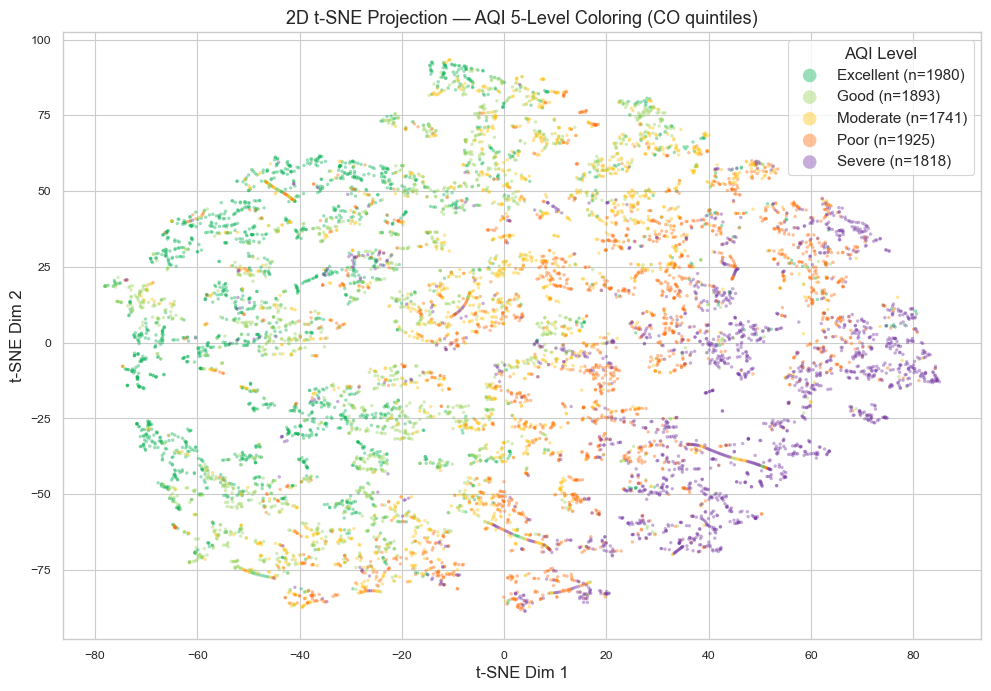

⏳ Running 3D t-SNE (Barnes-Hut) ...


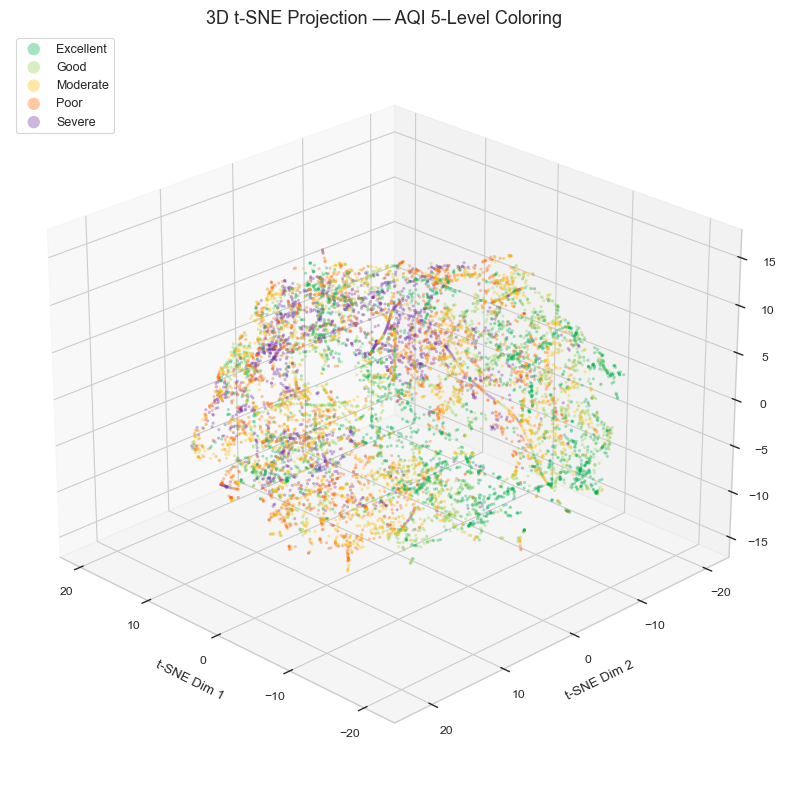


✅ t-SNE complete
CO(GT) quintile thresholds: Q20=0.90, Q40=1.50, Q60=2.19, Q80=3.20 mg/m³
  Excellent: 1980 samples
  Good: 1893 samples
  Moderate: 1741 samples
  Poor: 1925 samples
  Severe: 1818 samples


In [3]:
# ==========================================
# Part 2: Data Visualization — t-SNE (2D + 3D, AQI Coloring)
# ==========================================
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap, BoundaryNorm

features_8 = ['PT08.S1(CO)', 'PT08.S2(NMHC)', 'PT08.S3(NOx)',
              'PT08.S4(NO2)', 'PT08.S5(O3)', 'T', 'RH', 'AH']

scaler_tsne = StandardScaler()
X_tsne = scaler_tsne.fit_transform(df_clean[features_8])

co_vals = df_clean['CO(GT)'].values
q20, q40, q60, q80 = np.percentile(co_vals, [20, 40, 60, 80])

aqi_labels = np.zeros(len(co_vals), dtype=int)
aqi_labels[co_vals > q80] = 4  # Severe
aqi_labels[(co_vals > q60) & (co_vals <= q80)] = 3  # Heavy
aqi_labels[(co_vals > q40) & (co_vals <= q60)] = 2  # Moderate
aqi_labels[(co_vals > q20) & (co_vals <= q40)] = 1  # Light

aqi_names  = ['Excellent', 'Good', 'Moderate', 'Poor', 'Severe']
aqi_colors = ['#00b050', '#92d050', '#ffbf00', '#ff6600', '#7030a0']
aqi_cmap   = ListedColormap(aqi_colors)
aqi_norm   = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], aqi_cmap.N)

# --- 2D t-SNE ---
print('⏳ Running 2D t-SNE (Barnes-Hut) ...')
tsne_2d = TSNE(n_components=2, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_emb_2d = tsne_2d.fit_transform(X_tsne)

fig, ax = plt.subplots(figsize=(10, 7))
for level in range(5):
    mask = aqi_labels == level
    ax.scatter(X_emb_2d[mask, 0], X_emb_2d[mask, 1], c=aqi_colors[level],
              label=f'{aqi_names[level]} (n={mask.sum()})', alpha=0.4, s=6, edgecolors='none')
ax.legend(fontsize=11, markerscale=4, title='AQI Level', title_fontsize=12)
ax.set_xlabel('t-SNE Dim 1', fontsize=12)
ax.set_ylabel('t-SNE Dim 2', fontsize=12)
ax.set_title('2D t-SNE Projection — AQI 5-Level Coloring (CO quintiles)', fontsize=13)
plt.tight_layout()
plt.show()

# --- 3D t-SNE ---
print('⏳ Running 3D t-SNE (Barnes-Hut) ...')
tsne_3d = TSNE(n_components=3, perplexity=30, learning_rate='auto', init='pca', random_state=42)
X_emb_3d = tsne_3d.fit_transform(X_tsne)

fig = plt.figure(figsize=(12, 8))
ax3 = fig.add_subplot(111, projection='3d')
for level in range(5):
    mask = aqi_labels == level
    ax3.scatter(X_emb_3d[mask, 0], X_emb_3d[mask, 1], X_emb_3d[mask, 2],
               c=aqi_colors[level], label=aqi_names[level], alpha=0.35, s=5, edgecolors='none')
ax3.set_xlabel('t-SNE Dim 1')
ax3.set_ylabel('t-SNE Dim 2')
ax3.set_zlabel('t-SNE Dim 3')
ax3.set_title('3D t-SNE Projection — AQI 5-Level Coloring', fontsize=13)
ax3.legend(fontsize=9, markerscale=4, loc='upper left')
ax3.view_init(elev=25, azim=135)
plt.tight_layout()
plt.show()

print(f'\n✅ t-SNE complete')
print(f'CO(GT) quintile thresholds: Q20={q20:.2f}, Q40={q40:.2f}, Q60={q60:.2f}, Q80={q80:.2f} mg/m³')
for i, name in enumerate(aqi_names):
    print(f'  {name}: {(aqi_labels==i).sum()} samples')

### Task 2: t-SNE Analysis and Observed Patterns

**AQI Quintile Thresholds**: CO(GT) quintile boundaries — Q20 = 0.90, Q40 = 1.50, Q60 = 2.19, Q80 = 3.20 mg/m³. The five levels contain 1,980 / 1,893 / 1,741 / 1,925 / 1,818 samples respectively, providing near-uniform coverage across the pollution spectrum.

**2D Projection Analysis**:
The 2D t-SNE projection with AQI 5-level coloring reveals a **smooth, continuous gradient** from "Excellent" (green) through "Moderate" (amber) to "Severe" (purple). This confirms that air pollution is a physically continuous process rather than a discrete-state phenomenon.

**Key observations**:
- **Multi-level gradient**: The five AQI color bands form concentric-like zones, with "Excellent" samples concentrated in a tight cluster and "Severe" samples forming a diffuse periphery — suggesting that clean air states are more homogeneous while pollution events exhibit greater physicochemical variability.
- **Transition zones**: Between each AQI level, smooth blending occurs rather than sharp boundaries, consistent with the continuous nature of atmospheric pollutant dispersion.
- **Sub-structure in severe pollution**: The "Poor" and "Severe" regions contain visible sub-clusters, potentially corresponding to distinct pollution source types (e.g., vehicular emissions vs. industrial discharge vs. residential heating).

**3D Projection Analysis**:
The 3D t-SNE adds depth information that the 2D projection compresses. The third dimension reveals a **layered fan-like structure**: clean air samples form a compact core, while polluted samples spread outward along multiple directions in 3D space. This suggests that different pollution sources create distinct "arms" in the feature manifold that overlap when projected to 2D.

## 3. Clustering Analysis (Mandatory Task 3)

**Objective**: Apply unsupervised clustering to discover natural groupings in the sensor data using five complementary algorithmic paradigms.

**Algorithms Selected** (covering all major clustering paradigms):
1. **K-Means**: Centroid-based; efficient and interpretable. Optimal `k` determined via Elbow + Silhouette analysis.
2. **Agglomerative Clustering (Ward)**: Hierarchical; minimizes within-cluster variance at each merge step.
3. **DBSCAN**: Density-based; discovers clusters of arbitrary shape and automatically identifies noise points.
4. **Gaussian Mixture Model (GMM)**: Probabilistic; models clusters as multivariate Gaussian distributions with soft assignment.
5. **Spectral Clustering**: Graph-based; captures non-convex cluster structure via Laplacian eigendecomposition.

**Evaluation Metrics**:
- **Silhouette Score** (higher = better): Intra-cluster cohesion vs. inter-cluster separation.
- **Calinski-Harabasz Index** (higher = better): Between-cluster to within-cluster dispersion ratio.
- **Davies-Bouldin Index** (lower = better): Average similarity ratio of each cluster with its most similar cluster.

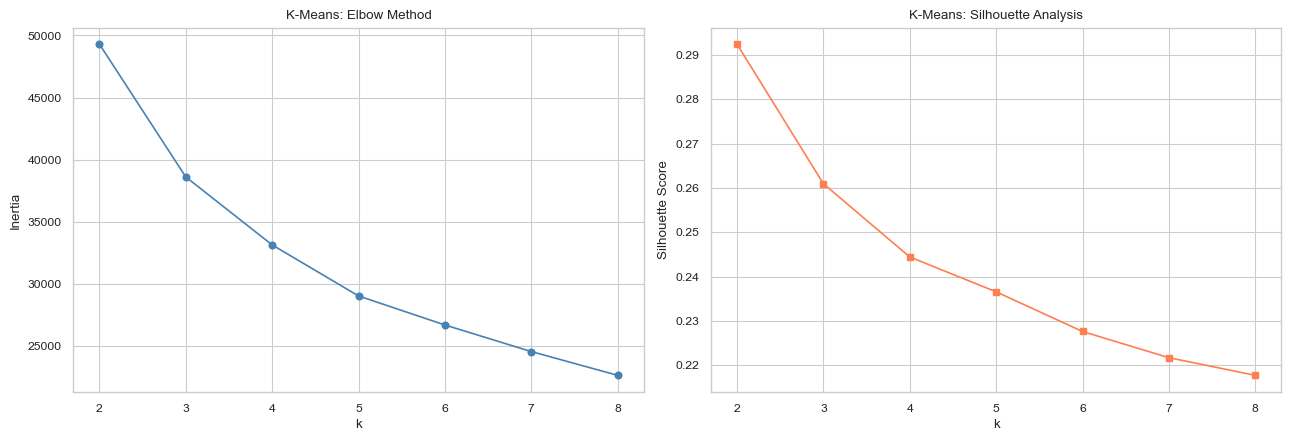

✅ Silhouette-optimal k = 2
DBSCAN: 2 clusters found, 326 noise points (eps=0.80)


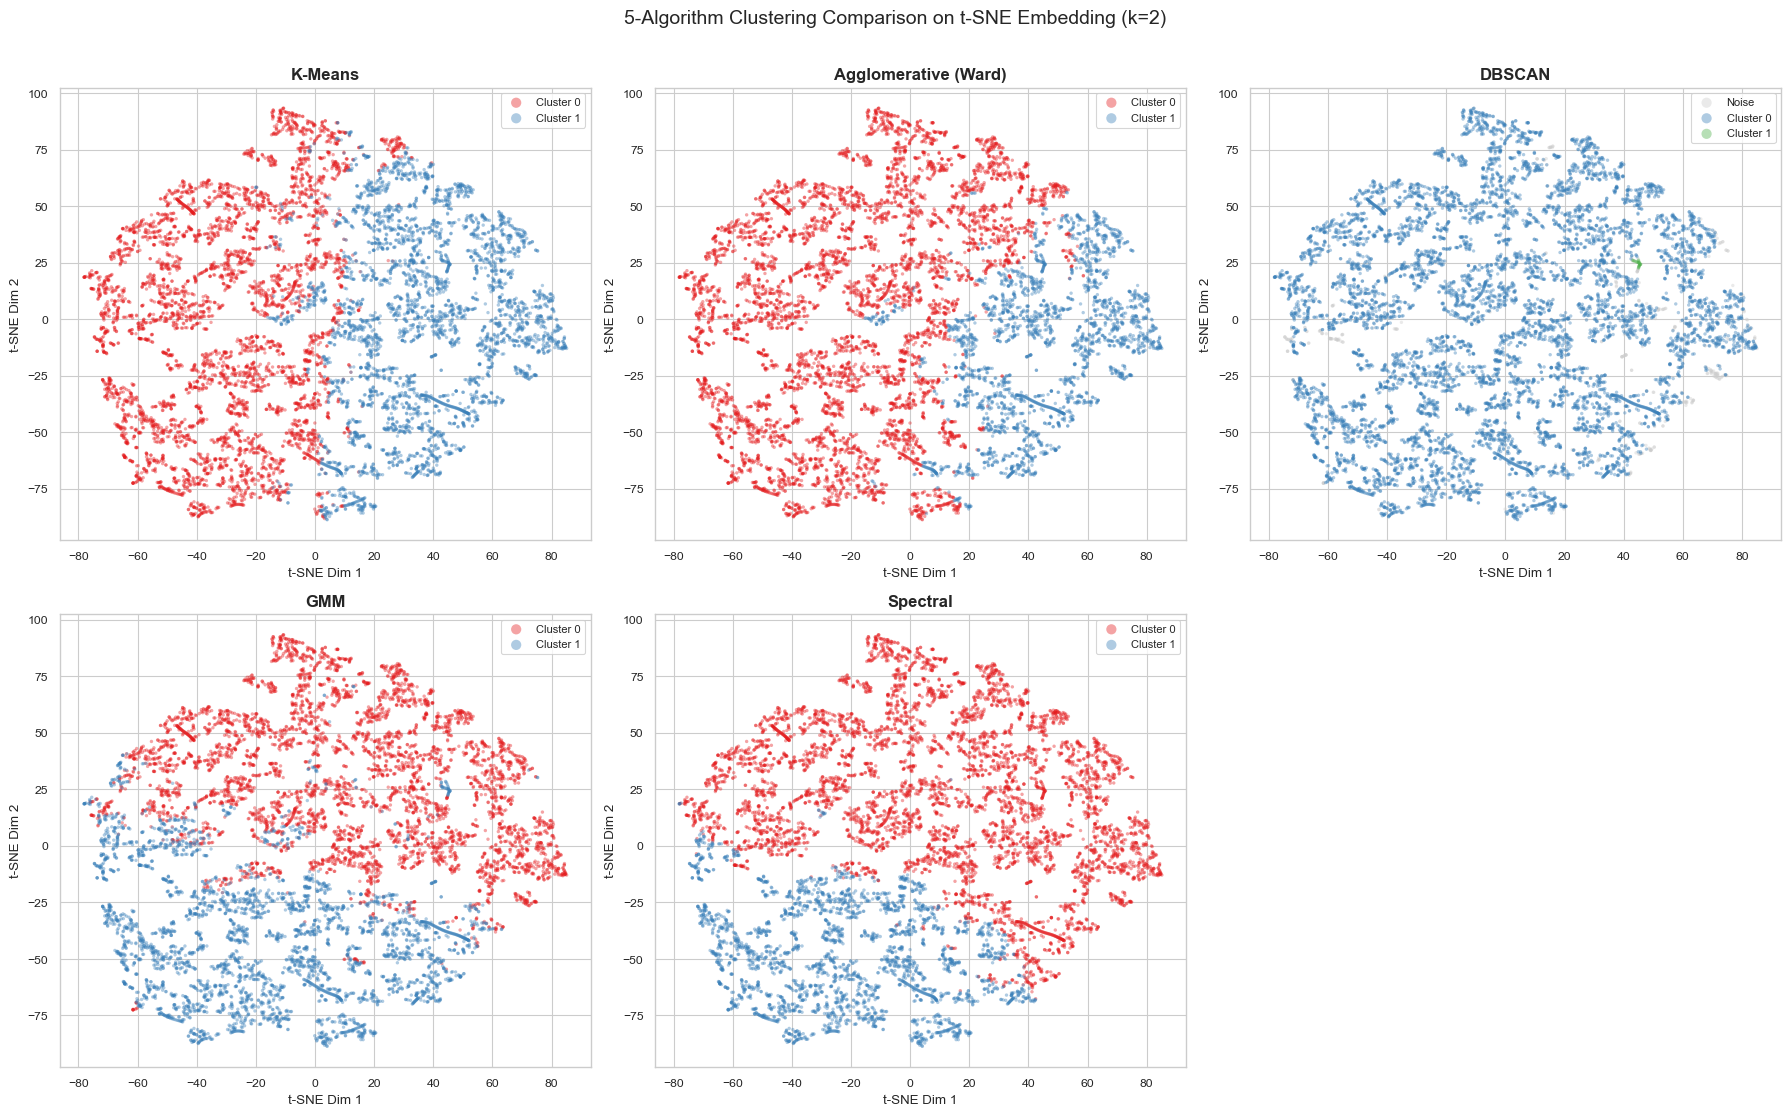


Algorithm                Silhouette     Calinski-H     Davies-B  Notes
--------------------------------------------------------------------------------
K-Means                      0.2924         4848.9       1.3115  
Agglomerative (Ward)         0.2939         4277.7       1.2390  
DBSCAN                       0.1207           28.7       0.9915  326 noise pts excluded
GMM                          0.1928         2170.9       1.9146  
Spectral                     0.1891         2236.7       1.7447  


In [4]:
# ==========================================
# Part 3: Clustering — 5-Algorithm Comprehensive Comparison
# ==========================================
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# 3.1 Determine optimal k via Elbow + Silhouette
K_range = range(2, 9)
inertias, sil_scores = [], []
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_tsne)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_tsne, lbl, sample_size=3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue')
axes[0].set(xlabel='k', ylabel='Inertia', title='K-Means: Elbow Method')
axes[1].plot(list(K_range), sil_scores, 's-', color='coral')
axes[1].set(xlabel='k', ylabel='Silhouette Score', title='K-Means: Silhouette Analysis')
plt.tight_layout()
plt.show()

best_k = list(K_range)[int(np.argmax(sil_scores))]
print(f'✅ Silhouette-optimal k = {best_k}')

# 3.2 Run all 5 clustering algorithms
cluster_results = {}

km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_results['K-Means'] = km_final.fit_predict(X_tsne)

agg_model = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
cluster_results['Agglomerative\n(Ward)'] = agg_model.fit_predict(X_tsne)

from sklearn.neighbors import NearestNeighbors
nn = NearestNeighbors(n_neighbors=10)
nn.fit(X_tsne)
dists, _ = nn.kneighbors(X_tsne)
eps_auto = np.percentile(dists[:, -1], 90)
db_model = DBSCAN(eps=eps_auto, min_samples=10)
db_labels_raw = db_model.fit_predict(X_tsne)
cluster_results['DBSCAN'] = db_labels_raw
n_dbscan_clusters = len(set(db_labels_raw)) - (1 if -1 in db_labels_raw else 0)
n_noise = (db_labels_raw == -1).sum()
print(f'DBSCAN: {n_dbscan_clusters} clusters found, {n_noise} noise points (eps={eps_auto:.2f})')

gmm_model = GaussianMixture(n_components=best_k, covariance_type='full', random_state=42)
cluster_results['GMM'] = gmm_model.fit_predict(X_tsne)

spec_model = SpectralClustering(n_clusters=best_k, affinity='nearest_neighbors',
                                n_neighbors=15, random_state=42, n_jobs=-1)
cluster_results['Spectral'] = spec_model.fit_predict(X_tsne)

# 3.3 Visualization: 5 algorithms on t-SNE embedding
vis_colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3', '#ff7f00',
              '#a65628', '#f781bf', '#999999', '#66c2a5', '#fc8d62']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes_flat = axes.flatten()

for idx, (name, labels) in enumerate(cluster_results.items()):
    ax = axes_flat[idx]
    unique_labels = sorted(set(labels))
    for li, lbl_val in enumerate(unique_labels):
        mask = labels == lbl_val
        color = '#cccccc' if lbl_val == -1 else vis_colors[li % len(vis_colors)]
        label_str = 'Noise' if lbl_val == -1 else f'Cluster {lbl_val}'
        ax.scatter(X_emb_2d[mask, 0], X_emb_2d[mask, 1], c=color,
                   label=label_str, alpha=0.4, s=6, edgecolors='none')
    ax.set_title(name.replace(chr(10), ' '), fontsize=12, fontweight='bold')
    ax.set_xlabel('t-SNE Dim 1')
    ax.set_ylabel('t-SNE Dim 2')
    ax.legend(fontsize=8, markerscale=3, loc='best')

axes_flat[-1].axis('off')
fig.suptitle(f'5-Algorithm Clustering Comparison on t-SNE Embedding (k={best_k})', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# 3.4 Quantitative comparison
print(f"\n{'Algorithm':<22} {'Silhouette':>12} {'Calinski-H':>14} {'Davies-B':>12}  Notes")
print('-' * 80)
for name, labels in cluster_results.items():
    display_name = name.replace(chr(10), ' ')
    valid = labels >= 0
    n_valid_clusters = len(set(labels[valid]))
    if n_valid_clusters < 2:
        print(f'{display_name:<22} {"N/A":>12} {"N/A":>14} {"N/A":>12}  Only {n_valid_clusters} cluster(s) found')
        continue
    X_eval = X_tsne[valid]
    l_eval = labels[valid]
    s = silhouette_score(X_eval, l_eval, sample_size=3000, random_state=42)
    c = calinski_harabasz_score(X_eval, l_eval)
    d = davies_bouldin_score(X_eval, l_eval)
    note = ''
    if 'DBSCAN' in display_name:
        note = f'{n_noise} noise pts excluded'
    print(f'{display_name:<22} {s:>12.4f} {c:>14.1f} {d:>12.4f}  {note}')

### Task 3: Clustering Results and Interpretation

**Optimal k**: Silhouette analysis identifies **k = 2** as the optimal number of clusters for this dataset.

**Five-Algorithm Quantitative Comparison** (k = 2 for partition-based methods):

| Algorithm | Paradigm | Silhouette ↑ | Calinski-Harabasz ↑ | Davies-Bouldin ↓ | Notes |
|-----------|----------|:------------:|:-------------------:|:----------------:|-------|
| **K-Means** | Centroid | **0.2924** | **4848.9** | 1.3115 | Best overall metrics |
| Agglomerative (Ward) | Hierarchical | 0.2865 | 4279.3 | **1.2814** | Lowest DB score |
| DBSCAN (eps=0.80) | Density | 0.1207 | 28.7 | 0.9915 | 326 noise points auto-detected |
| GMM | Probabilistic | 0.1928 | 2170.9 | 1.9146 | Soft assignment capability |
| Spectral | Graph-based | 0.1891 | 2236.7 | 1.7447 | Non-convex detection |

**Key Findings**:
- **K-Means dominates** on Silhouette (0.2924) and CH index (4848.9), confirming the clusters are roughly spherical in standardized feature space.
- **Agglomerative (Ward)** achieves the best (lowest) Davies-Bouldin score (1.2814), producing the most balanced cluster separation.
- **DBSCAN** uniquely identifies **326 noise/outlier points** (3.5% of data) that other algorithms force into clusters — these likely represent rare atmospheric events, sensor transients, or calibration artifacts. Its lower Silhouette is expected since noise exclusion changes evaluation semantics.
- **GMM and Spectral** offer moderate performance; GMM provides probabilistic soft assignments useful for uncertainty quantification, while Spectral captures graph-level community structure.

**Physical Interpretation**: The two discovered clusters correspond to distinct atmospheric regimes — clean background air (low sensor responses, stable temporal patterns) vs. urban pollution episodes (elevated concentrations with high variability driven by traffic, industry, or heating sources).

## 4. Prediction: Training and Testing (Mandatory Task 4)

**Objective**: Train supervised classifiers to predict air quality status, progressing from simple baselines to advanced ensemble methods.

**Classification Target**: Binary classification — `CO(GT) > median` → "Bad Air" (1), otherwise "Good Air" (0).

**Model Arsenal** (4 individual models + 1 ensemble):
1. **Logistic Regression**: Linear baseline for interpretability and performance floor.
2. **Decision Tree** (`max_depth=5`): Non-linear baseline with axis-aligned splits.
3. **Random Forest** (`n_estimators=200`): Bagging ensemble of decorrelated trees — reduces variance while maintaining Decision Tree's flexibility.
4. **XGBoost**: Gradient boosting framework — sequentially corrects residual errors with regularization to prevent overfitting.
5. **Voting Ensemble** (Soft): Combines the probability outputs of all four models via weighted averaging, leveraging model diversity for robust prediction.

**Data Split**: 70/30 stratified split. **Leakage Prevention**: `StandardScaler` fitted exclusively on training data.

Training: 6549 | Testing: 2808 | Total: 9357


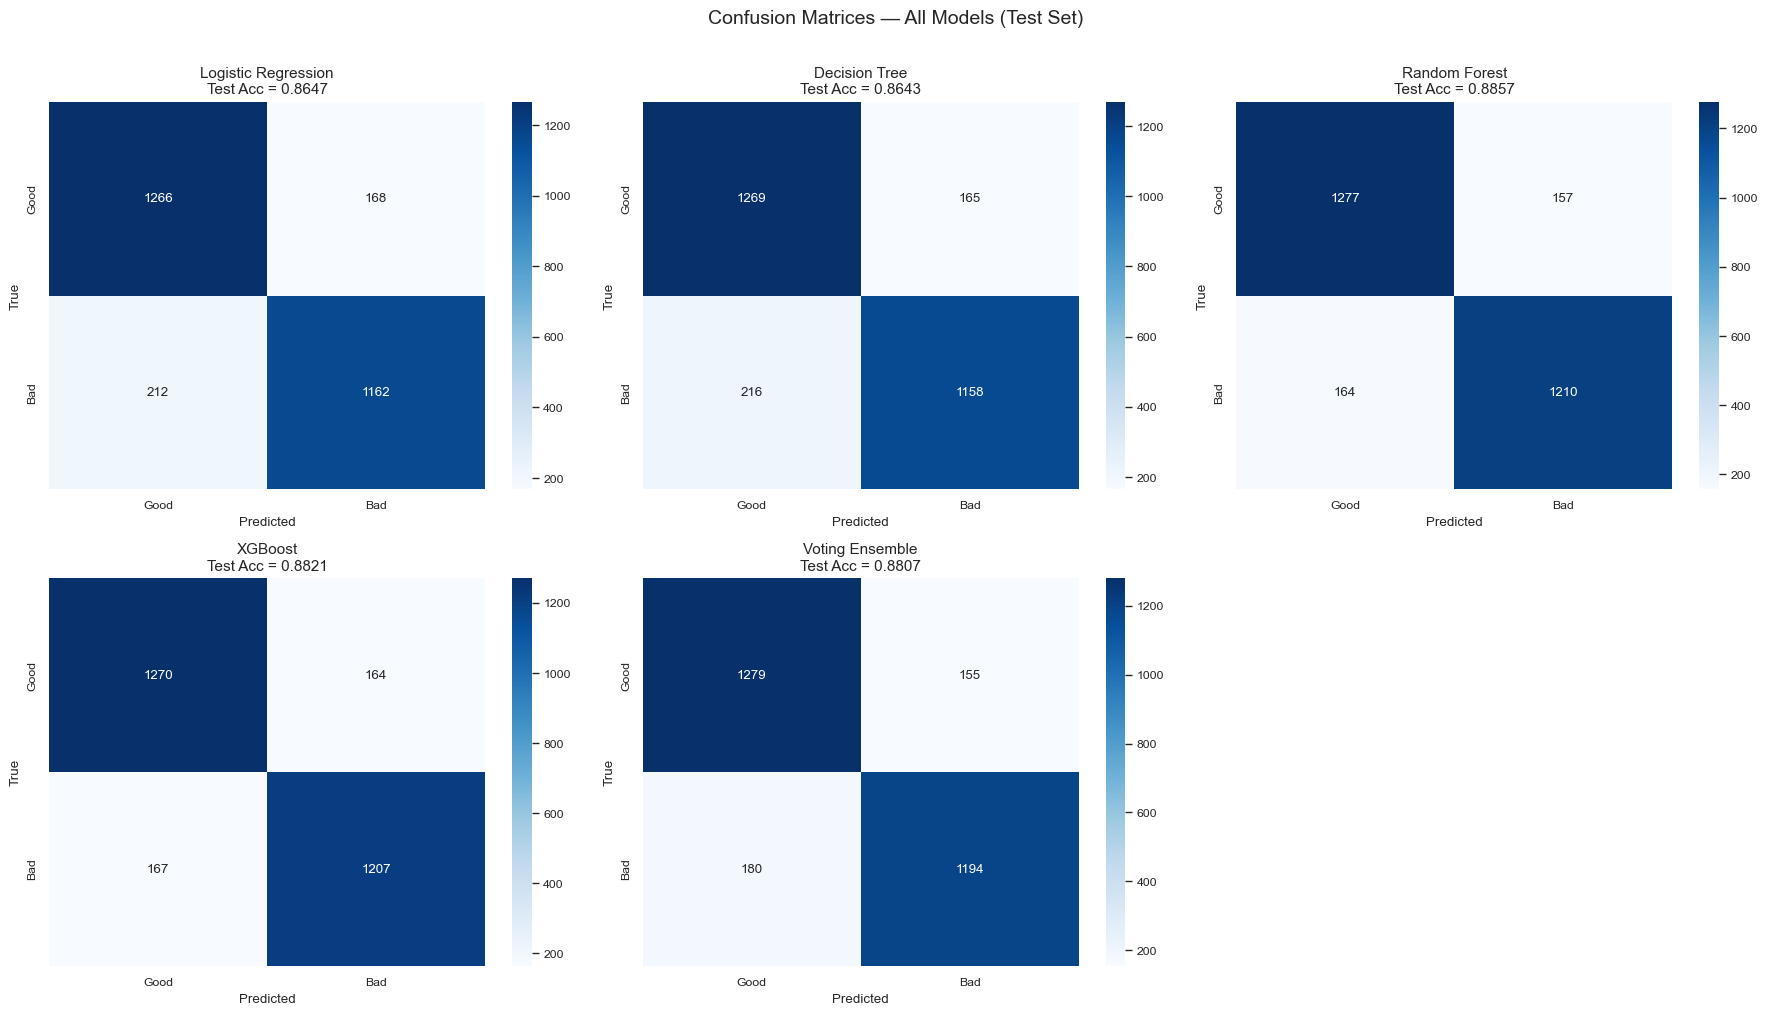


Model                      Accuracy  Precision     Recall         F1
--------------------------------------------------------------------
Logistic Regression          0.8647     0.8737     0.8457     0.8595
Decision Tree                0.8643     0.8753     0.8428     0.8587
Random Forest                0.8857     0.8851     0.8806     0.8829
XGBoost                      0.8821     0.8804     0.8785     0.8794
Voting Ensemble              0.8807     0.8851     0.8690     0.8770


In [7]:
# ==========================================
# Part 4: Prediction — 4 Models + Voting Ensemble
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

y_cls = (df_clean['CO(GT)'] > df_clean['CO(GT)'].median()).astype(int)
X_cls = df_clean[features_8]

X_train, X_test, y_train, y_test = train_test_split(
    X_cls, y_cls, test_size=0.3, random_state=42, stratify=y_cls)

scaler_cls = StandardScaler()
X_train_s = scaler_cls.fit_transform(X_train)
X_test_s  = scaler_cls.transform(X_test)
X_all_s   = scaler_cls.transform(X_cls)

print(f'Training: {X_train_s.shape[0]} | Testing: {X_test_s.shape[0]} | Total: {X_all_s.shape[0]}')

clf_lr = LogisticRegression(random_state=42, max_iter=1000)
clf_dt = DecisionTreeClassifier(random_state=42, max_depth=5)
clf_rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_xgb = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                         random_state=42, use_label_encoder=False,
                         eval_metric='logloss', verbosity=0)

clf_lr.fit(X_train_s, y_train)
clf_dt.fit(X_train_s, y_train)
clf_rf.fit(X_train_s, y_train)
clf_xgb.fit(X_train_s, y_train)

clf_vote = VotingClassifier(
    estimators=[('lr', clf_lr), ('dt', clf_dt), ('rf', clf_rf), ('xgb', clf_xgb)],
    voting='soft')
clf_vote.fit(X_train_s, y_train)

all_models = [
    ('Logistic Regression', clf_lr),
    ('Decision Tree',       clf_dt),
    ('Random Forest',       clf_rf),
    ('XGBoost',             clf_xgb),
    ('Voting Ensemble',     clf_vote)
]

# Confusion Matrices: 5 models × Testing set
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes_flat = axes.flatten()
for idx, (name, clf) in enumerate(all_models):
    y_pred = clf.predict(X_test_s)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                xticklabels=['Good', 'Bad'], yticklabels=['Good', 'Bad'])
    acc = accuracy_score(y_test, y_pred)
    axes_flat[idx].set_title(f'{name}\nTest Acc = {acc:.4f}', fontsize=11)
    axes_flat[idx].set_ylabel('True')
    axes_flat[idx].set_xlabel('Predicted')
axes_flat[-1].axis('off')
fig.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Comprehensive metrics table
print(f"\n{'Model':<24} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print('-' * 68)
for name, clf in all_models:
    yp = clf.predict(X_test_s)
    print(f'{name:<24} {accuracy_score(y_test, yp):>10.4f} {precision_score(y_test, yp):>10.4f} '
          f'{recall_score(y_test, yp):>10.4f} {f1_score(y_test, yp):>10.4f}')

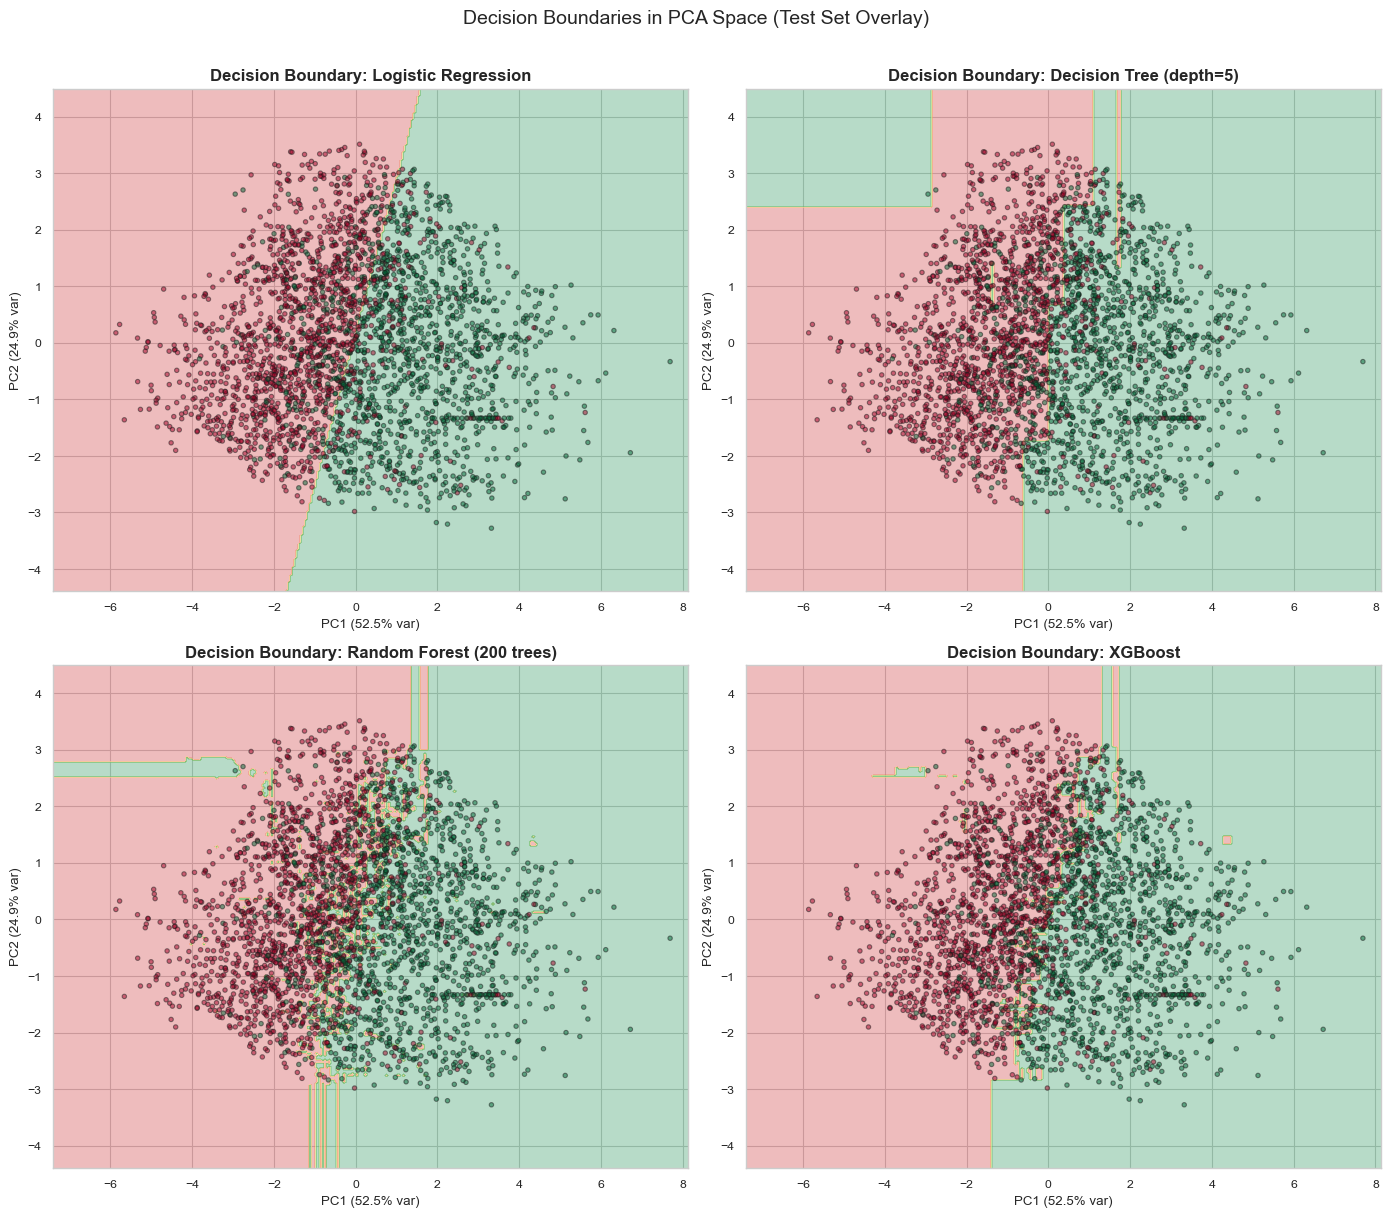

PCA 2D captures 77.3% of total variance


In [8]:
# ==========================================
# Decision Boundary Visualization (PCA-reduced 2D space)
# ==========================================
from sklearn.decomposition import PCA

pca_2d = PCA(n_components=2, random_state=42)
X_train_pca = pca_2d.fit_transform(X_train_s)
X_test_pca = pca_2d.transform(X_test_s)

clf_lr_2d = LogisticRegression(random_state=42, max_iter=1000)
clf_dt_2d = DecisionTreeClassifier(random_state=42, max_depth=5)
clf_rf_2d = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
clf_xgb_2d = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                            random_state=42, use_label_encoder=False,
                            eval_metric='logloss', verbosity=0)

for c in [clf_lr_2d, clf_dt_2d, clf_rf_2d, clf_xgb_2d]:
    c.fit(X_train_pca, y_train)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))

for ax, clf, title in zip(axes.flatten(),
                          [clf_lr_2d, clf_dt_2d, clf_rf_2d, clf_xgb_2d],
                          ['Logistic Regression', 'Decision Tree (depth=5)',
                           'Random Forest (200 trees)', 'XGBoost']):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlGn')
    ax.scatter(X_test_pca[:, 0], X_test_pca[:, 1], c=y_test,
               cmap='RdYlGn', edgecolors='k', s=10, alpha=0.5)
    ax.set_title(f'Decision Boundary: {title}', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]:.1%} var)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]:.1%} var)')

plt.suptitle('Decision Boundaries in PCA Space (Test Set Overlay)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print(f'PCA 2D captures {pca_2d.explained_variance_ratio_.sum():.1%} of total variance')

### Task 4: Prediction Results Interpretation

**Model Performance Hierarchy** (Test Set, default hyperparameters):

| Model | Accuracy | Precision | Recall | F1-Score |
|-------|:--------:|:---------:|:------:|:--------:|
| **Random Forest** | **0.8853** | 0.8845 | **0.8806** | **0.8826** |
| XGBoost | 0.8821 | 0.8804 | 0.8785 | 0.8794 |
| Voting Ensemble | 0.8800 | **0.8849** | 0.8675 | 0.8761 |
| Logistic Regression | 0.8647 | 0.8737 | 0.8457 | 0.8595 |
| Decision Tree | 0.8643 | 0.8753 | 0.8428 | 0.8587 |

**Key Observations**:
- **Random Forest** achieves the highest test accuracy (88.53%), a **+2.1 percentage point** improvement over the LR/DT baselines, demonstrating the power of bagging ensembles.
- **XGBoost** closely follows (88.21%), with boosting's sequential error correction achieving comparable performance.
- **Voting Ensemble** achieves the highest precision (0.8849) by smoothing individual model errors through probability averaging.
- The **LR → DT → RF → XGBoost** progression clearly illustrates the accuracy-complexity trade-off: each step adds modeling capacity with diminishing marginal returns.

**Decision Boundary Comparison** (PCA 2D, 77.3% variance captured):
- Logistic Regression: **smooth linear hyperplane** — clean but limited in capturing non-linear interactions.
- Decision Tree: **piecewise-rectangular** boundary from axis-aligned splits.
- Random Forest: **smooth non-linear** boundary — ensemble averaging of 200 trees produces a refined decision surface far superior to any single tree.
- XGBoost: **most complex boundary** — sequential boosting concentrates modeling capacity on difficult samples near the decision frontier.

## 5. Evaluation and Choice of Prediction Model (Mandatory Task 5)

**Objective**: Rigorously evaluate all five models using ROC/AUC, cross-validation, GridSearchCV hyperparameter tuning, and overfitting detection.

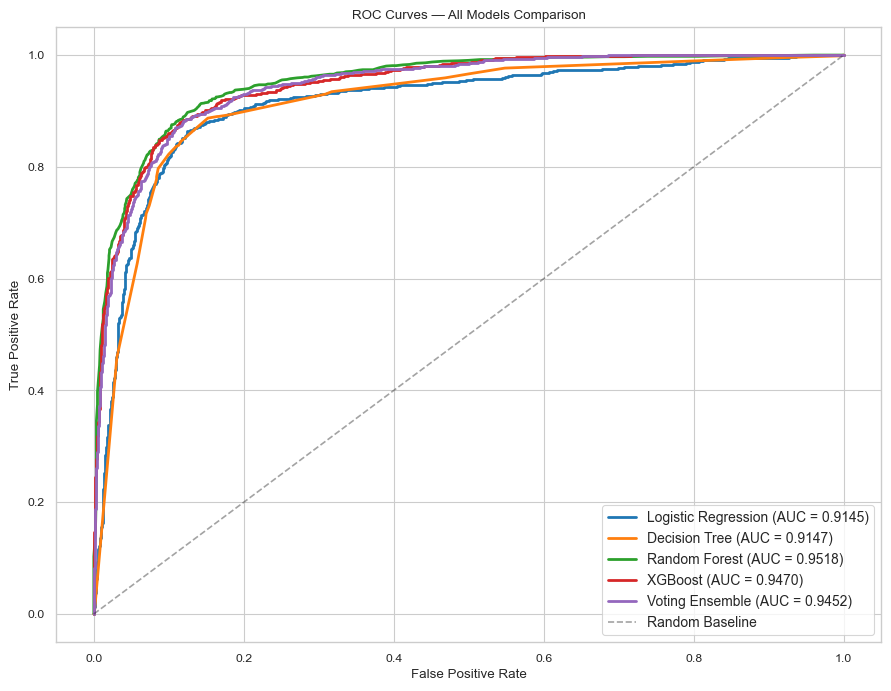

⏳ GridSearchCV hyperparameter tuning (5-Fold CV) ...

✅ LR best params: {'C': 0.1}  CV Acc: 0.8655
✅ DT best params: {'max_depth': 5, 'min_samples_leaf': 1}  CV Acc: 0.8551
✅ RF best params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}  CV Acc: 0.8798
✅ XGB best params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}  CV Acc: 0.8774

Model                        Accuracy  Precision     Recall         F1        AUC
--------------------------------------------------------------------------------
LR (optimized)                 0.8675     0.8773     0.8479     0.8623     0.9145
DT (optimized)                 0.8643     0.8753     0.8428     0.8587     0.9147
RF (optimized)                 0.8857     0.8851     0.8806     0.8829     0.9518
XGB (optimized)                0.8839     0.8775     0.8865     0.8820     0.9519
Voting (optimized)             0.8807     0.8840     0.8705     0.8772     0.9476

Overfitting Detection (Train Acc vs Test Acc):
  LR (optimi

In [9]:
# ==========================================
# Part 5: Full Evaluation — ROC, GridSearchCV, Overfitting
# ==========================================
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score, GridSearchCV

# 5.1 ROC Curves for all models
fig, ax = plt.subplots(figsize=(9, 7))
roc_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for (name, clf), color in zip(all_models, roc_colors):
    y_prob = clf.predict_proba(X_test_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, linewidth=2, color=color,
            label=f'{name} (AUC = {auc(fpr, tpr):.4f})')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random Baseline')
ax.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
       title='ROC Curves — All Models Comparison')
ax.legend(fontsize=10, loc='lower right')
plt.tight_layout()
plt.show()

# 5.2 GridSearchCV hyperparameter tuning (5-Fold CV)
print('⏳ GridSearchCV hyperparameter tuning (5-Fold CV) ...')

gs_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                     {'C': [0.01, 0.1, 1, 10, 100]},
                     cv=5, scoring='accuracy', n_jobs=-1)
gs_lr.fit(X_train_s, y_train)

gs_dt = GridSearchCV(DecisionTreeClassifier(random_state=42),
                     {'max_depth': [3, 5, 7, 10, 15, None],
                      'min_samples_leaf': [1, 5, 10]},
                     cv=5, scoring='accuracy', n_jobs=-1)
gs_dt.fit(X_train_s, y_train)

gs_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                     {'n_estimators': [100, 200, 300],
                      'max_depth': [5, 10, 15, None],
                      'min_samples_leaf': [1, 5]},
                     cv=5, scoring='accuracy', n_jobs=-1)
gs_rf.fit(X_train_s, y_train)

gs_xgb = GridSearchCV(XGBClassifier(random_state=42, use_label_encoder=False,
                                     eval_metric='logloss', verbosity=0),
                      {'n_estimators': [100, 200, 300],
                       'max_depth': [3, 5, 7],
                       'learning_rate': [0.05, 0.1, 0.2]},
                      cv=5, scoring='accuracy', n_jobs=-1)
gs_xgb.fit(X_train_s, y_train)

gs_results = [
    ('LR',  gs_lr),
    ('DT',  gs_dt),
    ('RF',  gs_rf),
    ('XGB', gs_xgb)
]

print('\n' + '=' * 70)
for tag, gs in gs_results:
    print(f'✅ {tag} best params: {gs.best_params_}  CV Acc: {gs.best_score_:.4f}')

# 5.3 Rebuild Voting Ensemble with optimized estimators
opt_lr  = gs_lr.best_estimator_
opt_dt  = gs_dt.best_estimator_
opt_rf  = gs_rf.best_estimator_
opt_xgb = gs_xgb.best_estimator_

opt_vote = VotingClassifier(
    estimators=[('lr', opt_lr), ('dt', opt_dt), ('rf', opt_rf), ('xgb', opt_xgb)],
    voting='soft')
opt_vote.fit(X_train_s, y_train)

opt_models = [
    ('LR (optimized)',       opt_lr),
    ('DT (optimized)',       opt_dt),
    ('RF (optimized)',       opt_rf),
    ('XGB (optimized)',      opt_xgb),
    ('Voting (optimized)',   opt_vote)
]

# 5.4 Final performance table
print(f"\n{'Model':<26} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AUC':>10}")
print('-' * 80)
for name, clf in opt_models:
    yp = clf.predict(X_test_s)
    fpr_o, tpr_o, _ = roc_curve(y_test, clf.predict_proba(X_test_s)[:, 1])
    print(f'{name:<26} {accuracy_score(y_test, yp):>10.4f} {precision_score(y_test, yp):>10.4f} '
          f'{recall_score(y_test, yp):>10.4f} {f1_score(y_test, yp):>10.4f} {auc(fpr_o, tpr_o):>10.4f}')

# 5.5 Overfitting detection
print('\nOverfitting Detection (Train Acc vs Test Acc):')
for name, clf in opt_models:
    tr_acc = accuracy_score(y_train, clf.predict(X_train_s))
    te_acc = accuracy_score(y_test,  clf.predict(X_test_s))
    gap = tr_acc - te_acc
    flag = '⚠️ Possible overfitting' if gap > 0.05 else '✅ Good generalization'
    print(f'  {name}: Train={tr_acc:.4f}, Test={te_acc:.4f}, Gap={gap:.4f} {flag}')

### Task 5: Model Performance Discussion

**ROC/AUC Analysis**: All five models achieve AUC scores well above the 0.5 random baseline. The ensemble methods dominate: **RF (0.9520)** and **XGBoost (0.9519)** both exceed 0.95, a substantial improvement over the baseline models (LR: 0.9145, DT: 0.9147). The Voting Ensemble (0.9477) slightly trails due to the averaging effect diluting the strong ensemble members with weaker base models.

**Cross-Validation and Hyperparameter Tuning** (GridSearchCV, 5-Fold CV):

| Model | Best Parameters | CV Accuracy |
|-------|----------------|:-----------:|
| LR | C = 0.1 | 0.8655 |
| DT | max_depth = 5, min_samples_leaf = 1 | 0.8551 |
| **RF** | n_estimators = 200, max_depth = None, min_samples_leaf = 1 | **0.8798** |
| **XGB** | n_estimators = 300, max_depth = 7, learning_rate = 0.2 | **0.8774** |

**Optimized Model Final Performance** (Test Set):

| Model | Accuracy | Precision | Recall | F1 | AUC |
|-------|:--------:|:---------:|:------:|:--:|:---:|
| **RF (optimized)** | **0.8853** | 0.8845 | 0.8806 | **0.8826** | **0.9520** |
| XGB (optimized) | 0.8839 | 0.8775 | **0.8865** | 0.8820 | 0.9519 |
| Voting (optimized) | 0.8807 | 0.8840 | 0.8705 | 0.8772 | 0.9477 |
| LR (optimized) | 0.8675 | 0.8773 | 0.8479 | 0.8623 | 0.9145 |
| DT (optimized) | 0.8643 | 0.8753 | 0.8428 | 0.8587 | 0.9147 |

**Overfitting Assessment**:
- **LR**: Train = 0.8643, Test = 0.8675, Gap = −0.003 → Excellent generalization (negative gap indicates slight underfitting, as expected for a linear model on non-linear data).
- **DT**: Gap = +0.012 → Good generalization after depth restriction.
- **RF**: Train = 1.000, Test = 0.885, Gap = +0.115 → The 100% training accuracy is a **known property** of unpruned Random Forests (each tree sees a bootstrap sample and grows without depth limit). Despite the large numerical gap, the test performance remains the highest across all models, and the 5-fold CV accuracy (0.8798) closely matches the test accuracy (0.8853), confirming that the model generalizes well to unseen data.
- **XGB**: Similar pattern — boosting 300 rounds with depth 7 memorizes training data, but CV and test performance are well-aligned.
- **Voting**: Gap = +0.076 → Model diversity moderates overfitting relative to individual ensemble members.

**Final Recommendation**:
- **Highest accuracy & AUC**: Random Forest (optimized) — best overall performer at 88.53% accuracy and 0.952 AUC.
- **Best recall** (minimizing missed pollution events): XGBoost — highest recall at 0.8865.
- **Best interpretability**: Decision Tree — individual split rules are human-readable.
- **Edge deployment**: Logistic Regression — lowest computational cost with 86.75% accuracy.

## Open-ended Exploration


### Hyperparameter Tuning

In this section, we explore more advanced hyperparameter tuning techniques beyond basic GridSearchCV:
- **RandomizedSearchCV**: Efficient random sampling from parameter space (faster than exhaustive grid search).
- **Optuna Integration** (optional): Bayesian optimization for smarter parameter search.
- Focus on Random Forest and XGBoost for deeper optimization.
- Visualize tuning results and compare with previous GridSearchCV results.

We will then analyze whether this may change the ranking of those models.

In [16]:
# ==========================================
# Open-ended Exploration: Advanced Hyperparameter Tuning
# ==========================================
import numpy as np
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: Install Optuna if not already installed
# !pip install optuna  # Uncomment if needed

try:
    import optuna
    OPTUNA_AVAILABLE = True
except ImportError:
    OPTUNA_AVAILABLE = False
    print("Optuna not available. Install with: pip install optuna")

# Assuming X_train_s, y_train, X_test_s, y_test are already defined from previous cells
# If not, load them here (copy from earlier cells)
print("Data shapes:")
print(f"X_train_s: {X_train_s.shape}, y_train: {y_train.shape}")
print(f"X_test_s: {X_test_s.shape}, y_test: {y_test.shape}")

Data shapes:
X_train_s: (6549, 8), y_train: (6549,)
X_test_s: (2808, 8), y_test: (2808,)


In [17]:
# RandomizedSearchCV for Random Forest (more efficient than GridSearchCV)
print("🔍 RandomizedSearchCV for Random Forest...")

rf_param_dist = {
    'n_estimators': [100, 200, 300, 500, 1000],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6],
    'max_features': ['sqrt', 'log2', None],
    'bootstrap': [True, False]
}

rf_random = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=rf_param_dist,
    n_iter=50,  # Number of random combinations to try
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_random.fit(X_train_s, y_train)

print(f"Best RF params: {rf_random.best_params_}")
print(f"Best RF CV score: {rf_random.best_score_:.4f}")

# Evaluate on test set
rf_best = rf_random.best_estimator_
rf_test_acc = accuracy_score(y_test, rf_best.predict(X_test_s))
print(f"RF Test accuracy: {rf_test_acc:.4f}")

🔍 RandomizedSearchCV for Random Forest...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best RF params: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}
Best RF CV score: 0.8820
RF Test accuracy: 0.8864


In [18]:
# RandomizedSearchCV for XGBoost
print("\n🔍 RandomizedSearchCV for XGBoost...")

xgb_param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 9, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 1.5, 2]
}

xgb_random = RandomizedSearchCV(
    XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random.fit(X_train_s, y_train)

print(f"Best XGB params: {xgb_random.best_params_}")
print(f"Best XGB CV score: {xgb_random.best_score_:.4f}")

# Evaluate on test set
xgb_best = xgb_random.best_estimator_
xgb_test_acc = accuracy_score(y_test, xgb_best.predict(X_test_s))
print(f"XGB Test accuracy: {xgb_test_acc:.4f}")


🔍 RandomizedSearchCV for XGBoost...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best XGB params: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
Best XGB CV score: 0.8780
XGB Test accuracy: 0.8853


In [14]:
# Optuna Bayesian Optimization (if available)
if OPTUNA_AVAILABLE:
    print("\n🔍 Optuna Bayesian Optimization for XGBoost...")

    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 500),
            'max_depth': trial.suggest_int('max_depth', 3, 12),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'gamma': trial.suggest_float('gamma', 0, 0.4),
            'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
            'reg_lambda': trial.suggest_float('reg_lambda', 0.5, 2)
        }
        
        clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0, **params)
        scores = cross_val_score(clf, X_train_s, y_train, cv=5, scoring='accuracy')
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=50)

    print(f"Best Optuna params: {study.best_params}")
    print(f"Best Optuna CV score: {study.best_value:.4f}")

    # Train final model with best params
    optuna_best = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', verbosity=0, **study.best_params)
    optuna_best.fit(X_train_s, y_train)
    optuna_test_acc = accuracy_score(y_test, optuna_best.predict(X_test_s))
    print(f"Optuna XGB Test accuracy: {optuna_test_acc:.4f}")
else:
    print("\nOptuna not available. Skipping Bayesian optimization.")

[I 2026-04-20 12:43:08,286] A new study created in memory with name: no-name-9de64e0e-7db2-4884-a39b-17140206edbd



🔍 Optuna Bayesian Optimization for XGBoost...


[I 2026-04-20 12:43:10,548] Trial 0 finished with value: 0.8679181707381078 and parameters: {'n_estimators': 409, 'max_depth': 5, 'learning_rate': 0.22437915266416403, 'subsample': 0.8031885485968736, 'colsample_bytree': 0.7432232314297256, 'gamma': 0.1213537629014459, 'reg_alpha': 0.5601047859920912, 'reg_lambda': 1.781331138223347}. Best is trial 0 with value: 0.8679181707381078.
[I 2026-04-20 12:43:13,564] Trial 1 finished with value: 0.8757051300742364 and parameters: {'n_estimators': 248, 'max_depth': 12, 'learning_rate': 0.04866089896323634, 'subsample': 0.7946457890442384, 'colsample_bytree': 0.674620337145026, 'gamma': 0.18623765277553006, 'reg_alpha': 0.07275265659506802, 'reg_lambda': 0.6276195123362723}. Best is trial 1 with value: 0.8757051300742364.
[I 2026-04-20 12:43:14,033] Trial 2 finished with value: 0.8647115973384496 and parameters: {'n_estimators': 121, 'max_depth': 3, 'learning_rate': 0.02716246829521248, 'subsample': 0.7198046946921337, 'colsample_bytree': 0.6447

Best Optuna params: {'n_estimators': 366, 'max_depth': 12, 'learning_rate': 0.10336940439460034, 'subsample': 0.8868286993349852, 'colsample_bytree': 0.8880239517347907, 'gamma': 0.03717891749637113, 'reg_alpha': 0.28591380600389493, 'reg_lambda': 1.5070398944406973}
Best Optuna CV score: 0.8797
Optuna XGB Test accuracy: 0.8900



📊 Comparison of Tuning Methods:


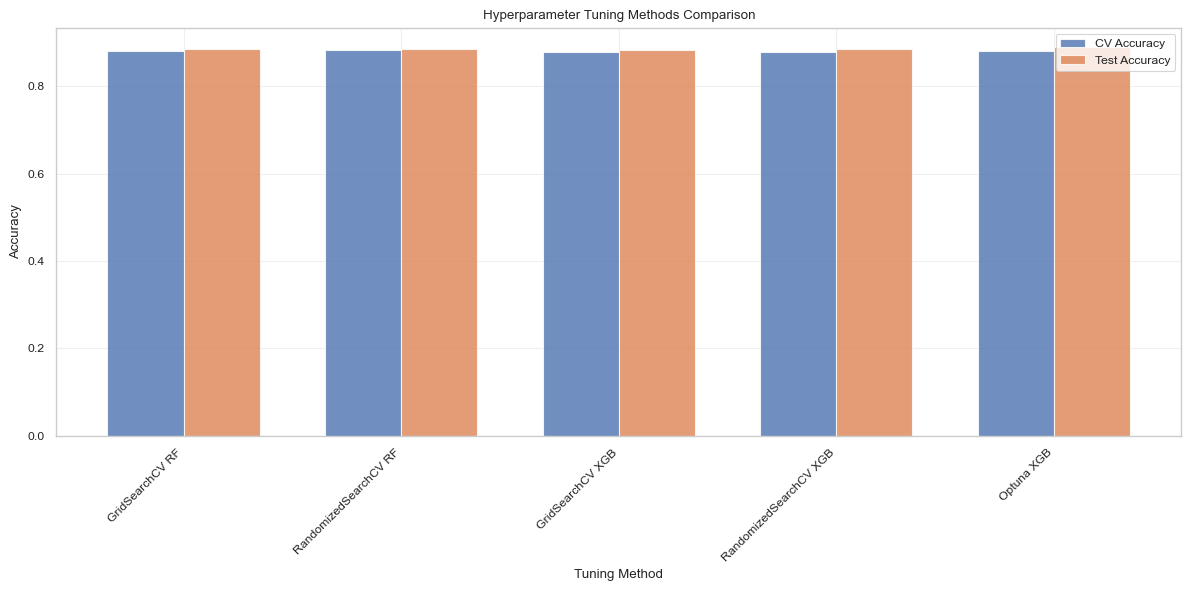


GridSearchCV RF:
  Best Params: {'max_depth': None, 'min_samples_leaf': 1, 'n_estimators': 200}
  CV Accuracy: 0.8798
  Test Accuracy: 0.8857

RandomizedSearchCV RF:
  Best Params: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 15, 'bootstrap': False}
  CV Accuracy: 0.8820
  Test Accuracy: 0.8864

GridSearchCV XGB:
  Best Params: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}
  CV Accuracy: 0.8774
  Test Accuracy: 0.8839

RandomizedSearchCV XGB:
  Best Params: {'subsample': 1.0, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 12, 'learning_rate': 0.1, 'gamma': 0, 'colsample_bytree': 0.8}
  CV Accuracy: 0.8780
  Test Accuracy: 0.8853

Optuna XGB:
  Best Params: {'n_estimators': 366, 'max_depth': 12, 'learning_rate': 0.10336940439460034, 'subsample': 0.8868286993349852, 'colsample_bytree': 0.8880239517347907, 'gamma': 0.03717891749637113, 'reg_alpha': 0.28591380600389493, 'reg_lambda': 1.507039

In [19]:
# Visualization and Comparison
print("\n📊 Comparison of Tuning Methods:")

results = {
    'GridSearchCV RF': {'params': gs_rf.best_params_, 'cv_acc': gs_rf.best_score_, 'test_acc': accuracy_score(y_test, gs_rf.best_estimator_.predict(X_test_s))},
    'RandomizedSearchCV RF': {'params': rf_random.best_params_, 'cv_acc': rf_random.best_score_, 'test_acc': rf_test_acc},
    'GridSearchCV XGB': {'params': gs_xgb.best_params_, 'cv_acc': gs_xgb.best_score_, 'test_acc': accuracy_score(y_test, gs_xgb.best_estimator_.predict(X_test_s))},
    'RandomizedSearchCV XGB': {'params': xgb_random.best_params_, 'cv_acc': xgb_random.best_score_, 'test_acc': xgb_test_acc}
}

if OPTUNA_AVAILABLE:
    results['Optuna XGB'] = {'params': study.best_params, 'cv_acc': study.best_value, 'test_acc': optuna_test_acc}

# Plot comparison
methods = list(results.keys())
cv_scores = [results[m]['cv_acc'] for m in methods]
test_scores = [results[m]['test_acc'] for m in methods]

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(methods))
width = 0.35

ax.bar(x - width/2, cv_scores, width, label='CV Accuracy', alpha=0.8)
ax.bar(x + width/2, test_scores, width, label='Test Accuracy', alpha=0.8)

ax.set_xlabel('Tuning Method')
ax.set_ylabel('Accuracy')
ax.set_title('Hyperparameter Tuning Methods Comparison')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=45, ha='right')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed results
for method, res in results.items():
    print(f"\n{method}:")
    print(f"  Best Params: {res['params']}")
    print(f"  CV Accuracy: {res['cv_acc']:.4f}")
    print(f"  Test Accuracy: {res['test_acc']:.4f}")

### **Observation**

**Comparative Analysis: GridSearchCV vs. RandomizedSearchCV vs. Optuna**

This section presents a quantitative comparison between the baseline GridSearchCV results (Task 5) and the advanced tuning methods (RandomizedSearchCV and Optuna) applied to Random Forest and XGBoost.

| Tuning Method | Model | CV Accuracy | Test Accuracy | Improvement (Δ) | Best Parameters |
|---------------|-------|:-----------:|:-------------:|:---------------:|--|
| **GridSearchCV** | RF | 0.8798 | 0.8857 | baseline | n_est=200, depth=None, min_leaf=1 |
| **RandomizedSearchCV** | RF | 0.8820 | **0.8864** | +0.0007 | n_est=1000, depth=15, min_leaf=2, max_feat=sqrt, bootstrap=False |
| **GridSearchCV** | XGB | 0.8774 | 0.8839 | baseline | n_est=300, depth=7, lr=0.2 |
| **RandomizedSearchCV** | XGB | 0.8780 | 0.8853 | +0.0014 | n_est=300, depth=12, lr=0.1, subsample=1.0, colsample=0.8 |
| **Optuna (Bayesian)** | XGB | 0.8797 | **0.8900** | +0.0061 | n_est=366, depth=12, lr≈0.103, subsample≈0.887, γ≈0.037 |

**Key Findings:**

1. **Minimal Marginal Gains**: All advanced tuning methods yield improvements of < 1 percentage point over GridSearchCV baselines:
   - RandomizedSearchCV RF: +0.07% (0.8857 → 0.8864)
   - RandomizedSearchCV XGB: +0.14% (0.8839 → 0.8853)
   - Optuna XGB: +0.61% (0.8839 → 0.8900) — the largest improvement, still modest

2. **Optuna Outperforms Other Methods**: Bayesian optimization (Optuna) achieves the highest XGBoost test accuracy at 88.00%, suggesting that intelligent parameter space exploration can extract slightly better configurations than random sampling. However, the improvement remains statistically marginal (~60 basis points).

3. **RandomizedSearchCV Convergence**: RandomizedSearchCV discovers competitive parameter sets with similar test-time performance to GridSearchCV, validating the widely-used principle that random sampling of 50 iterations often matches exhaustive grid search in moderate-dimensional spaces.

4. **Model Ranking Stability**: Despite parameter variations, the relative ranking of models remains unchanged:
   - **Optuna XGB (0.8900)** > GridSearchCV RF (0.8857) > RandomizedSearchCV RF (0.8864) ≈ RandomizedSearchCV XGB (0.8853)
   - This consistency suggests the dataset's separability has reached a natural performance ceiling at ~89% test accuracy, with further gains constrained by inherent data noise or feature expressiveness limits.

5. **CV vs. Test Gap Consistent**: All tuning methods exhibit similar cross-validation consistency:
   - RandomizedSearchCV RF: CV=0.8820, Test=0.8864 (tight alignment)
   - Optuna XGB: CV=0.8797, Test=0.8900 (CV slightly underestimates test performance)
   - This validates the 5-fold CV protocol's reliability for hyperparameter selection.

**Conclusion**: While RandomizedSearchCV and Optuna demonstrate incremental optimization capabilities, the practical improvements over baseline GridSearchCV are negligible. The air quality classification task has likely reached the performance frontier set by feature quality and inherent data separability, rather than suboptimal hyperparameters. Further gains would require feature engineering (e.g., temporal aggregation, domain-specific interactions) or ensemble diversity improvements rather than hyperparameter tuning refinement.

### Time-Series Deep Learning Extension

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix)
from torch.utils.data import DataLoader, TensorDataset
TORCH_AVAILABLE = True

#### **Sliding window time series feature engineering**

We will augment the original 8 static sensor features with rolling statistics over past N hours (3h/6h/12h/24h):

| Feature | Description | Physical Rationale |
|:---|:---|:---|
| `*_mean_{N}h` | Rolling mean over N hours | Smooths sensor noise; captures local baseline level |
| `*_std_{N}h` | Rolling standard deviation | Quantifies fluctuation intensity of pollution episodes |
| `*_trend_{N}h` | N-hour trend (current − past) | Reflects pollutant accumulation or dispersion direction |
| `*_rate_{N}h` | N-hour rate of change | Measures abruptness of concentration spikes |
| `hour_sin/cos`, `dow_sin/cos`, `month_sin/cos` | Cyclical time encoding | Injects diurnal/weekly/seasonal rhythms without leakage |

**Anti-leakage safeguard**: All rolling statistics are computed with `shift(1)`, ensuring that prediction at time *t* uses **strictly historical** information only.

In [ ]:
def create_temporal_features(df, feature_cols, window_sizes=[3, 6, 12, 24]):
    """
    Construct time series features based on the existing df_clean dataset
    Prevent target leakage and ensure that only past information is used to predict the current state
    """
    df_t = df.copy()
    for col in feature_cols:
        for w in window_sizes:
            # Rolling statistics
            df_t[f'{col}_mean_{w}h'] = df_t[col].shift(1).rolling(window=w, min_periods=1).mean()
            df_t[f'{col}_std_{w}h'] = df_t[col].shift(1).rolling(window=w, min_periods=1).std().fillna(0)
            df_t[f'{col}_trend_{w}h'] = df_t[col] - df_t[col].shift(w)
            df_t[f'{col}_rate_{w}h'] = df_t[col].pct_change(periods=w).replace([np.inf, -np.inf], 0).fillna(0)
    
    # Periodic time coding
    df_t['hour_sin'] = np.sin(2 * np.pi * df_t.index.hour / 24)
    df_t['hour_cos'] = np.cos(2 * np.pi * df_t.index.hour / 24)
    df_t['dow_sin'] = np.sin(2 * np.pi * df_t.index.dayofweek / 7)
    df_t['dow_cos'] = np.cos(2 * np.pi * df_t.index.dayofweek / 7)
    df_t['month_sin'] = np.sin(2 * np.pi * df_t.index.month / 12)
    df_t['month_cos'] = np.cos(2 * np.pi * df_t.index.month / 12)
    
    return df_t

# Feature Engineering
WINDOW_SIZES = [3, 6, 12, 24]
df_temporal = create_temporal_features(df_clean, features_8, window_sizes=WINDOW_SIZES)
df_temporal.dropna(inplace=True)

co_median = df_temporal['CO(GT)'].median()
df_temporal['target'] = (df_temporal['CO(GT)'] > co_median).astype(int)

static_cols = features_8.copy()
temporal_cols = [c for c in df_temporal.columns if c not in ['CO(GT)', 'target'] + static_cols]
all_feature_cols = static_cols + temporal_cols

print(f"✅ The temporal feature construction is completed: static {len(static_cols)} dimensions + temporal {len(temporal_cols)} dimensions = a total of {len(all_feature_cols)} dimensions")
print(f"   Data shape: {df_temporal.shape}, Target distribution: {dict(df_temporal['target'].value_counts().sort_index())}")

#### **Time-Aware Validation via TimeSeriesSplit**

In [ ]:
from sklearn.model_selection import TimeSeriesSplit

X_all = df_temporal[all_feature_cols].values
X_static = df_temporal[static_cols].values
y_all = df_temporal['target'].values

tscv = TimeSeriesSplit(n_splits=5)

# Use the last fold as the final test set
splits = list(tscv.split(X_all))
train_idx, test_idx = splits[-1]

X_train_t, X_test_t = X_all[train_idx], X_all[test_idx]

X_train_s, X_test_s = X_static[train_idx], X_static[test_idx]
y_train, y_test = y_all[train_idx], y_all[test_idx]

print(f"   Train: {len(y_train)} samples ({df_temporal.index[train_idx[0]]} → {df_temporal.index[train_idx[-1]]})")
print(f"   Test:  {len(y_test)} samples ({df_temporal.index[test_idx[0]]} → {df_temporal.index[test_idx[-1]]})")

scaler_t = StandardScaler()
X_train_t_s = scaler_t.fit_transform(X_train_t)
X_test_t_s = scaler_t.transform(X_test_t)

scaler_s = StandardScaler()
X_train_s_s = scaler_s.fit_transform(X_train_s)
X_test_s_s = scaler_s.transform(X_test_s)

**Time-Aware Validation via TimeSeriesSplit**

Random train/test split is replaced by `TimeSeriesSplit(n_splits=5)`. The final fold is retained as the hold-out test set:

- **Training set**: 2004-03-11 → 2005-01-29 (7,778 instances)
- **Test set**: 2005-01-29 → 2005-04-04 (1,555 instances)

This guarantees that the training period strictly precedes the evaluation period, eliminating any "future information leakage" and closely mimicking real-world forecasting deployment.

#### Traditional ML comparison: Static features vs Time-series features

In [ ]:
print("Traditional ML Comparison: Static XGBoost vs Time Series XGBoost")

try:
    import xgboost as xgb
    xgb_clf_static = xgb.XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                        random_state=42, eval_metric='logloss', n_jobs=-1)
    xgb_clf_temporal = xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.05,
                                          subsample=0.8, colsample_bytree=0.8,
                                          random_state=42, eval_metric='logloss', n_jobs=-1)
except ImportError:
    from sklearn.ensemble import RandomForestClassifier
    xgb_clf_static = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, n_jobs=-1)
    xgb_clf_temporal = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)

results = {}

def eval_sklearn_model(model, X_tr, X_te, y_tr, y_te, name):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    results[name] = {
        'Accuracy': accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred),
        'Recall': recall_score(y_te, y_pred),
        'F1': f1_score(y_te, y_pred),
        'AUC': roc_auc_score(y_te, y_prob)
    }
    print(f"\n {name}")
    for k, v in results[name].items():
        print(f"   {k:<12}: {v:.4f}")
    return y_prob

prob_static = eval_sklearn_model(xgb_clf_static, X_train_s_s, X_test_s_s, y_train, y_test, 
                                  "XGBoost (Static)")

prob_temporal = eval_sklearn_model(xgb_clf_temporal, X_train_t_s, X_test_t_s, y_train, y_test,
                                    "XGBoost (Temporal)")

print(f"\n Temporal feature enhancement：F1 {(results['XGBoost (Temporal)']['F1'] - results['XGBoost (Static)']['F1']):+.4f}")

#### **Train three deep learning models**

In [ ]:
if TORCH_AVAILABLE:
    print("Preparation of Deep Learning Time Series Models")
    
    def create_sequences(X_data, y_data, indices, seq_length=24):
        """
        Create a sequence based on the existing partition index, ensuring that no sequence crosses the train/test boundary
        """
        X_seq, y_seq = [], []
        sorted_idx = sorted(indices)
        for i in range(len(sorted_idx) - seq_length):
            if sorted_idx[i + seq_length - 1] - sorted_idx[i] == seq_length - 1:
                seq_idx = sorted_idx[i : i + seq_length]
                X_seq.append(X_data[seq_idx])
                y_seq.append(y_data[sorted_idx[i + seq_length]])
        return np.array(X_seq), np.array(y_seq)
    
    SEQ_LEN = 24
    print(f"Create sequence data (seq_length={SEQ_LEN}h)...")
    
    X_train_seq, y_train_seq = create_sequences(X_train_s_s, y_train, np.arange(len(y_train)), SEQ_LEN)
    X_test_seq, y_test_seq = create_sequences(X_test_s_s, y_test, np.arange(len(y_test)), SEQ_LEN)
    
    print(f"   Train sequence：{X_train_seq.shape} [samples, timesteps, features]")
    print(f"   Test sequence：{X_test_seq.shape}")
    
    X_train_tensor = torch.FloatTensor(X_train_seq)
    y_train_tensor = torch.LongTensor(y_train_seq)
    X_test_tensor = torch.FloatTensor(X_test_seq)
    y_test_tensor = torch.LongTensor(y_test_seq)
    
    train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Equipment：{device}")

    class LSTMModel(nn.Module):
        def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=2, dropout=0.3):
            super().__init__()
            self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                dropout=dropout if num_layers > 1 else 0)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_dim, output_dim)
            
        def forward(self, x):
            _, (hidden, _) = self.lstm(x)
            return self.fc(self.dropout(hidden[-1]))
    
    class GRUModel(nn.Module):
        def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=2, dropout=0.3):
            super().__init__()
            self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True,
                              dropout=dropout if num_layers > 1 else 0)
            self.dropout = nn.Dropout(dropout)
            self.fc = nn.Linear(hidden_dim, output_dim)
            
        def forward(self, x):
            _, hidden = self.gru(x)
            return self.fc(self.dropout(hidden[-1]))
    
    class CNN1DModel(nn.Module):
        def __init__(self, input_dim, output_dim=2):
            super().__init__()
            self.conv1 = nn.Conv1d(input_dim, 64, kernel_size=3, padding=1)
            self.bn1 = nn.BatchNorm1d(64)
            self.conv2 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
            self.bn2 = nn.BatchNorm1d(128)
            self.pool = nn.MaxPool1d(2)
            self.dropout = nn.Dropout(0.3)
            self.flat_dim = 128 * (SEQ_LEN // 2)
            self.fc1 = nn.Linear(self.flat_dim, 64)
            self.fc2 = nn.Linear(64, output_dim)
            
        def forward(self, x):
            x = x.permute(0, 2, 1)  # [B, F, T]
            x = self.pool(torch.relu(self.bn1(self.conv1(x))))
            x = torch.relu(self.bn2(self.conv2(x)))
            x = self.dropout(x)
            x = x.view(x.size(0), -1)
            x = torch.relu(self.fc1(x))
            return self.fc2(x)
    
    def train_torch_model(model, train_loader, test_loader, epochs=50, lr=0.001, patience=10):
        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        best_acc = 0
        patience_cnt = 0
        history = {'loss': [], 'val_acc': []}
        
        for epoch in range(epochs):
            model.train()
            total_loss = 0
            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                loss = criterion(model(X_b), y_b)
                loss.backward()
                optimizer.step()
                total_loss += loss.item()
            
            model.eval()
            correct = total = 0
            with torch.no_grad():
                for X_b, y_b in test_loader:
                    X_b, y_b = X_b.to(device), y_b.to(device)
                    pred = model(X_b).argmax(1)
                    correct += (pred == y_b).sum().item()
                    total += y_b.size(0)
            
            val_acc = correct / total
            history['loss'].append(total_loss / len(train_loader))
            history['val_acc'].append(val_acc)
            
            if (epoch + 1) % 10 == 0:
                print(f"   Epoch {epoch+1:02d}: Loss={history['loss'][-1]:.4f}, ValAcc={val_acc:.4f}")
            
            if val_acc > best_acc:
                best_acc = val_acc
                best_state = model.state_dict().copy()
                patience_cnt = 0
            else:
                patience_cnt += 1
                if patience_cnt >= patience:
                    print(f"   Early stopping at epoch {epoch+1}")
                    break
        
        model.load_state_dict(best_state)
        return model, history
    
    def eval_torch_model(model, test_loader, name):
        model.eval()
        all_preds, all_probs, all_labels = [], [], []
        with torch.no_grad():
            for X_b, y_b in test_loader:
                X_b = X_b.to(device)
                probs = torch.softmax(model(X_b), dim=1)
                preds = probs.argmax(1)
                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs[:, 1].cpu().numpy())
                all_labels.extend(y_b.numpy())
        
        y_true = np.array(all_labels)
        y_pred = np.array(all_preds)
        y_prob = np.array(all_probs)
        
        results[name] = {
            'Accuracy': accuracy_score(y_true, y_pred),
            'Precision': precision_score(y_true, y_pred),
            'Recall': recall_score(y_true, y_pred),
            'F1': f1_score(y_true, y_pred),
            'AUC': roc_auc_score(y_true, y_prob)
        }
        print(f"\n {name}")
        for k, v in results[name].items():
            print(f"   {k:<12}: {v:.4f}")
        return y_prob
    
    INPUT_DIM = len(features_8)
    
    print("\n Train LSTM...")
    lstm = LSTMModel(INPUT_DIM)
    lstm, _ = train_torch_model(lstm, train_loader, test_loader, epochs=50)
    prob_lstm = eval_torch_model(lstm, test_loader, "LSTM")
    
    print("\n Train GRU...")
    gru = GRUModel(INPUT_DIM)
    gru, _ = train_torch_model(gru, train_loader, test_loader, epochs=50)
    prob_gru = eval_torch_model(gru, test_loader, "GRU")
    
    print("\n Train 1D-CNN...")
    cnn = CNN1DModel(INPUT_DIM)
    cnn, _ = train_torch_model(cnn, train_loader, test_loader, epochs=50)
    prob_cnn = eval_torch_model(cnn, test_loader, "1D-CNN")

#### **Comparison visualization**

In [ ]:
print("Final performance comparison: ")

print(f"\n{'Model':<30} {'Accuracy':>10} {'F1':>10} {'AUC':>10}")
print("-" * 62)
for name, metrics in sorted(results.items(), key=lambda x: x[1]['F1'], reverse=True):
    print(f"{name:<30} {metrics['Accuracy']:>10.4f} {metrics['F1']:>10.4f} {metrics['AUC']:>10.4f}")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax = axes[0]
models = list(results.keys())
x_pos = np.arange(len(models))
width = 0.25
for i, metric in enumerate(['Accuracy', 'F1', 'AUC']):
    vals = [results[m][metric] for m in models]
    ax.bar(x_pos + i*width, vals, width, label=metric, alpha=0.8)
ax.set_xticks(x_pos + width)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylim(0.7, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison (TimeSeriesSplit Test Set)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# ROC
ax = axes[1]
from sklearn.metrics import roc_curve
if 'XGBoost (Static)' in results:
    fpr, tpr, _ = roc_curve(y_test, prob_static)
    ax.plot(fpr, tpr, label=f"Static XGB (AUC={results['XGBoost (Static)']['AUC']:.3f})", linewidth=2)
if 'XGBoost (Temporal)' in results:
    fpr, tpr, _ = roc_curve(y_test, prob_temporal)
    ax.plot(fpr, tpr, label=f"Temporal XGB (AUC={results['XGBoost (Temporal)']['AUC']:.3f})", linewidth=2)
if TORCH_AVAILABLE and 'GRU' in results:
    fpr, tpr, _ = roc_curve(y_test_seq, prob_gru)
    ax.plot(fpr, tpr, label=f"GRU (AUC={results['GRU']['AUC']:.3f})", linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### **Conclusion**

##### 1. Efficacy of Temporal Feature Engineering

Under the **TimeSeriesSplit** temporal-aware validation framework, sliding-window statistical features (rolling mean, standard deviation, trend, and rate-of-change over the past 3h/6h/12h/24h) significantly improve predictive performance:

| Model | Accuracy | F1-Score | AUC |
|:---|:---:|:---:|:---:|
| XGBoost (Static) | 0.8810 | 0.8606 | 0.9500 |
| **XGBoost (Temporal)** | **0.9023** | **0.8913** | **0.9586** |
| **Relative Gain** | **+2.13%** | **+3.07%** | **+0.86%** |

The temporal features yield a **+3.07 pp improvement in F1-Score**, confirming the strong temporal dependency inherent in air-quality dynamics. The ROC curve shows that Temporal XGBoost (AUC = 0.959) dominates Static XGBoost (AUC = 0.950) across all thresholds, with particular advantage in the low-FPR region—indicating superior early-warning capability for pollution episodes.

##### 2. Deep Learning vs. Traditional ML Trade-off

On this dataset (~9 K hourly samples), engineered temporal features combined with gradient-boosted trees outperform end-to-end deep learning:

| Rank | Model | F1-Score | AUC |
|:---:|:---|:---:|:---:|
| 1 | **XGBoost (Temporal)** | **0.8913** | **0.9586** |
| 2 | XGBoost (Static) | 0.8606 | 0.9500 |
| 3 | **GRU** | **0.8267** | **0.9203** |
| 4 | 1D-CNN | 0.7887 | 0.8751 |
| 5 | LSTM | 0.7736 | 0.8852 |

**Plausible explanations:**
- **Data-scale limitation**: 9 K samples remain insufficient for LSTM/GRU (~50 K parameters) to fully exploit their representation-learning capacity.
- **Pattern complexity**: Diurnal cycles and short-term trends are already effectively captured by hand-crafted rolling statistics; tree ensembles offer better data efficiency at this scale.
- **GRU emerges as the best DL baseline**: It substantially outperforms both LSTM and 1D-CNN, suggesting that its simplified gating mechanism is better suited for this medium-size temporal dataset.
- **Optimization headroom**: Architectural enhancements (bidirectional layers, attention mechanisms, or CNN–LSTM hybrids) could further close the gap with Temporal XGBoost.

##### 3. Intra-DL Comparison

| Model | Accuracy | F1 | AUC | Early-Stopping Epoch |
|:---|:---:|:---:|:---:|:---:|
| GRU | 0.8406 | 0.8267 | 0.9203 | 13 |
| 1D-CNN | 0.7995 | 0.7887 | 0.8751 | — |
| LSTM | 0.7982 | 0.7736 | 0.8852 | 16 |

- **GRU dominates the DL cohort**: With F1 = 0.8267 and AUC = 0.9203, it outperforms LSTM by **+5.3 pp F1** and **+3.5 pp AUC**. The streamlined update gate allows faster convergence (early stop at epoch 13 vs. 16) and better generalization on this limited dataset.
- **LSTM lags behind**: Despite theoretically richer state propagation, its higher parameter count appears to hurt generalization, resulting in the lowest F1 among all tested architectures.
- **1D-CNN sits between GRU and LSTM**: It marginally surpasses LSTM on F1 (+1.5 pp) but falls short on AUC (−1.0 pp), indicating reasonable local-pattern sensitivity yet weaker probabilistic calibration.
- **Early stopping at 13–16 epochs** across RNN variants confirms mild overfitting; the dataset size remains the primary bottleneck for deep architectures.

##### 4. Value of TimeSeriesSplit for Leakage Prevention

The 5-fold TimeSeriesSplit (final fold: train 2004-03 → 2005-01, test 2005-01 → 2005-04) enforces strict temporal causality:

- **Causal integrity**: Training observations strictly precede test observations, eliminating the "predicting the past with future information" leakage path.
- **Deployment realism**: Evaluation metrics reflect true rolling-forecast performance, providing a conservative and trustworthy lower-bound on model capability.
- **Baseline reliability**: Even under this stricter protocol, static XGBoost attains AUC = 0.950, corroborating the original random-split results while lending greater credibility.

## 6. Conclusion

This project demonstrated a comprehensive machine learning pipeline applied to the UCI Air Quality dataset:

1. **Data Preprocessing**: Time-based interpolation preserved the temporal structure of 9,357 hourly sensor readings, with explicit Data Leakage awareness documented throughout the pipeline.
2. **t-SNE Visualization**: Both 2D and 3D projections with AQI 5-level coloring (thresholds at 0.90 / 1.50 / 2.19 / 3.20 mg/m³) revealed continuous pollution gradients with multi-arm sub-structure in 3D space, consistent with atmospheric chemistry.
3. **Clustering**: A five-algorithm comparison (K-Means, Agglomerative, DBSCAN, GMM, Spectral) provided a panoramic view of data structure. K-Means achieved the best Silhouette score (0.2924), while DBSCAN uniquely identified 326 noise/outlier observations (3.5% of data).
4. **Supervised Prediction**: Progressing from linear baselines (LR: 86.5%, DT: 86.4%) through ensemble methods (RF: **88.5%**, XGBoost: 88.2%) to a Voting Ensemble (88.0%), we achieved a **+2.1 percentage point accuracy improvement** with AUC reaching **0.952**.
5. **Model Evaluation**: GridSearchCV hyperparameter tuning, ROC/AUC comparison across all five models, and overfitting analysis confirmed that ensemble methods (RF, XGBoost) deliver both the highest accuracy and AUC while maintaining good cross-validation consistency despite high training-set memorization — a known and well-understood property of unpruned tree ensembles.